# Robustness at scale on an implicit sampler: 30-var low-rank Gaussian, 107 constraints, 7 false

This scales the [robust_false_constraint_large](robust_false_constraint_large.ipynb) study off the
tensor network and onto a **reparametrised sampler** (`calibrated_response.maxent_sampler.SamplerModel`).

**Setup**
- **30 continuous variables** drawn from a Gaussian with a **rank-4 covariance** (genuine correlations).
- **107 constraints** read off that ground truth: 30 means `E[x_i]`, 47 threshold probabilities
  `P(x_i > t)`, and 30 pairwise products `E[x_i x_j]` — expectation constraints on one or two variables.
- **7 of the threshold probabilities are planted FALSE** (target flipped to the opposite extreme), each
  on a variable whose true mean stays as an anchor, so the conflict is genuine (1-against-rest).

Every constraint enters as an `onoff` robust constraint: a belief `E[f] = target` protected by a
**learnable Bernoulli credence** the optimiser can lower (convicting the constraint) at a KL cost of
`-log p_broken`. The key contrast with the tensor network: those 107 "constraint variables" become
**107 credence *gate parameters*, not 107 extra sampled dimensions** — there is no 137-site network
to wire, just a 30-output sampler plus a length-107 gate vector. `credences(params)` reads them back.

We compare two fits of the *same* 107 statements:

| fit | how the constraints enter |
|---|---|
| **ordinary (hard)** | every constraint a hard squared-error term, weighted `1/(2·value_sd²)` — no notion of trust |
| **onoff robust** | every constraint gated by its own 2-state credence |


## 0. Setup — ground truth, 107 constraints, and the 7 planted lies

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")
import numpy as np
import matplotlib.pyplot as plt
from calibrated_response.tn import ContinuousVar
from calibrated_response.maxent_sampler import (
    SamplerModel, moment, product, soft_gt, hard_gt, plot_pairwise)

# ---- scale knobs (shrink STEPS for a quick smoke test) ----
NV, RANK, N_FALSE = 30, 4, 7
STEPS, LR, NS, SEED = 3000, 0.02, 4096, 0
rng = np.random.default_rng(SEED)

# ---- ground truth: low-rank Gaussian  Sigma = B B^T + diag(d) ----
mu = rng.uniform(30, 70, NV)
B = rng.normal(0, 1, (NV, RANK)) * 5.0
d = rng.uniform(4.0, 9.0, NV)
Sigma = B @ B.T + np.diag(d)
sd = np.sqrt(np.diag(Sigma))

# reference sample: constraint targets are read off it, so they are achievable in-domain
NREF = 200_000
Zc = rng.normal(size=(NREF, RANK)); eps = rng.normal(size=(NREF, NV)) * np.sqrt(d)
Xref = mu + Zc @ B.T + eps
lo, hi = mu - 5 * sd, mu + 5 * sd
Xref = np.clip(Xref, lo, hi)

vars = [ContinuousVar(f"x{i}", float(lo[i]), float(hi[i]), 32) for i in range(NV)]

# ---- 107 constraints: dict(name, f, target, value_sd, is_false, true_target, kind[, _pi,_pt]) ----
cons = []
# 30 means (anchors)
for i in range(NV):
    t = float(Xref[:, i].mean())
    cons.append(dict(name=f"E[x{i}]", kind="mean", f=moment(i, 1),
                     target=t, true_target=t, value_sd=0.05 * sd[i], is_false=False))
# 47 threshold probs  P(x_i > t)  (soft target under the SAME surrogate the loss uses)
sharp = 4.0 / sd
for _ in range(47):
    i = int(rng.integers(NV)); t = float(mu[i] + rng.uniform(-1, 1) * sd[i])
    p = float(np.mean(1.0 / (1.0 + np.exp(-sharp[i] * (Xref[:, i] - t)))))
    cons.append(dict(name=f"P(x{i}>{t:.0f})", kind="prob",
                     f=soft_gt(i, t, sharpness=float(sharp[i])),
                     target=p, true_target=p, value_sd=0.03, is_false=False, _pi=i, _pt=t))
# 30 pairwise products  E[x_i x_j]  (two-variable / covariance constraints)
for _ in range(NV):
    i, j = (int(a) for a in rng.choice(NV, size=2, replace=False))
    v = Xref[:, i] * Xref[:, j]
    cons.append(dict(name=f"E[x{i}x{j}]", kind="prod", f=product(i, j),
                     target=float(v.mean()), true_target=float(v.mean()),
                     value_sd=0.05 * (float(v.std()) + 1e-9), is_false=False, _pi=i, _pj=j))

# ---- plant 7 lies among the threshold probs (flip target; keep the true mean anchor) ----
prob_idx = [k for k, c in enumerate(cons) if c["kind"] == "prob"]
false_k = sorted(int(k) for k in rng.choice(prob_idx, size=N_FALSE, replace=False))
for k in false_k:
    cons[k]["target"] = 0.05 if cons[k]["true_target"] > 0.5 else 0.95
    cons[k]["is_false"] = True
is_false = np.array([c["is_false"] for c in cons])
false_vars = sorted({cons[k]["_pi"] for k in false_k})

onoff_list = [("onoff", c["f"], None, c["target"], c["value_sd"]) for c in cons]
hard_list  = [("expect", c["f"], c["target"], 1.0 / (2.0 * c["value_sd"] ** 2)) for c in cons]

print(f"{NV} variables, {len(cons)} constraints, {int(is_false.sum())} planted false "
      f"({100*is_false.mean():.0f}%) on variables {false_vars}")
for k in false_k:
    print(f"  #{k:3d}  {cons[k]['name']:12s} target={cons[k]['target']:.2f}  "
          f"(true {cons[k]['true_target']:.2f}, anchor E[x{cons[k]['_pi']}]={mu[cons[k]['_pi']]:.1f})")

30 variables, 107 constraints, 7 planted false (7%) on variables [0, 1, 4, 5, 20, 23, 28]
  # 30  P(x23>48)    target=0.05  (true 0.81, anchor E[x23]=55.9)
  # 43  P(x20>30)    target=0.05  (true 0.59, anchor E[x20]=31.1)
  # 48  P(x4>49)     target=0.05  (true 0.78, anchor E[x4]=62.5)
  # 56  P(x5>70)     target=0.95  (true 0.33, anchor E[x5]=66.5)
  # 57  P(x28>58)    target=0.95  (true 0.43, anchor E[x28]=57.4)
  # 69  P(x0>55)     target=0.05  (true 0.53, anchor E[x0]=55.5)
  # 71  P(x1>38)     target=0.05  (true 0.70, anchor E[x1]=40.8)


## 1. Ordinary fit — all 107 constraints hard

Every constraint is a hard squared-error term weighted `1/(2·value_sd²)` (the same precision the robust
fit uses), with no notion of trust. The 7 false probabilities cannot be reconciled with their variables'
true means, so the optimiser splits the difference — corrupting the fit with nothing to flag which
statements were the liars.

In [2]:
def fitted_moments(model, p, n=20000, seed=7):
    X = model.sample(p, n, seed=seed)
    return X.mean(0), np.cov(X.T)

sm_h = SamplerModel(vars, latent_dim=8, hidden_sizes=[128, 128])
p_h, hist_h = sm_h.optimize(sm_h.constraint_loss(hard_list, n_samples=NS),
                            backend="adam", steps=STEPS, lr=LR)
mean_h, cov_h = fitted_moments(sm_h, p_h)
err_h = np.abs(mean_h - mu)
print(f"ordinary (all hard):  mean|E[x]-truth| = {err_h.mean():.2f}   max = {err_h.max():.2f}")
print(f"  on the {len(false_vars)} corrupted variables {false_vars}: err = {np.round(err_h[false_vars],2)}")

ordinary (all hard):  mean|E[x]-truth| = 0.36   max = 1.74
  on the 7 corrupted variables [0, 1, 4, 5, 20, 23, 28]: err = [0.36 0.26 0.83 1.43 0.15 0.34 1.74]


## 2. Onoff robust fit — every constraint gated by its own credence

Same 107 statements, but each enters as an `("onoff", f, given, target, value_sd)` constraint: a learnable
Bernoulli credence `q` gates a division-free residual `w·(q·(E[f]-target))²` plus `KL(Bernoulli(q) ‖
Bernoulli(1-p_broken))`. Convicting a constraint (`q → 0`) costs exactly `-log p_broken ≈ 3` nats and
switches its pull off. The 7 false constraints flee to broken while the 100 true ones stay near the
prior `0.95`. Read the credences straight off the fitted params.

In [3]:
sm_r = SamplerModel(vars, latent_dim=8, hidden_sizes=[128, 128])
p_r, hist_r = sm_r.optimize(sm_r.constraint_loss(onoff_list, n_samples=NS),
                            backend="adam", steps=STEPS, lr=LR)
cred = sm_r.credences(p_r)
mean_r, cov_r = fitted_moments(sm_r, p_r)
err_r = np.abs(mean_r - mu)

tt, tf = cred[~is_false], cred[is_false]
auc = np.mean([1.0*(a < b) + 0.5*(a == b) for a in tf for b in tt])
print(f"onoff robust (all 107):  mean|E[x]-truth| = {err_r.mean():.2f}   max = {err_r.max():.2f}")
print(f"  credence TRUE : min {tt.min():.2f}  mean {tt.mean():.2f}   (want ~0.95)")
print(f"  credence FALSE: max {tf.max():.2f}  mean {tf.mean():.2f}   (want ~0)")
print(f"  separation AUC (false ranked below true) = {auc:.3f}")
for k in false_k:
    print(f"  {cons[k]['name']:12s} target={cons[k]['target']:.2f}  credence={cred[k]:.3f}")

onoff robust (all 107):  mean|E[x]-truth| = 0.12   max = 0.41
  credence TRUE : min 0.94  mean 0.95   (want ~0.95)
  credence FALSE: max 0.10  mean 0.06   (want ~0)
  separation AUC (false ranked below true) = 1.000
  P(x23>48)    target=0.05  credence=0.012
  P(x20>30)    target=0.05  credence=0.057
  P(x4>49)     target=0.05  credence=0.012
  P(x5>70)     target=0.95  credence=0.096
  P(x28>58)    target=0.95  credence=0.026
  P(x0>55)     target=0.05  credence=0.100
  P(x1>38)     target=0.05  credence=0.089


## 3. The picture — recovery, trust, and who got believed

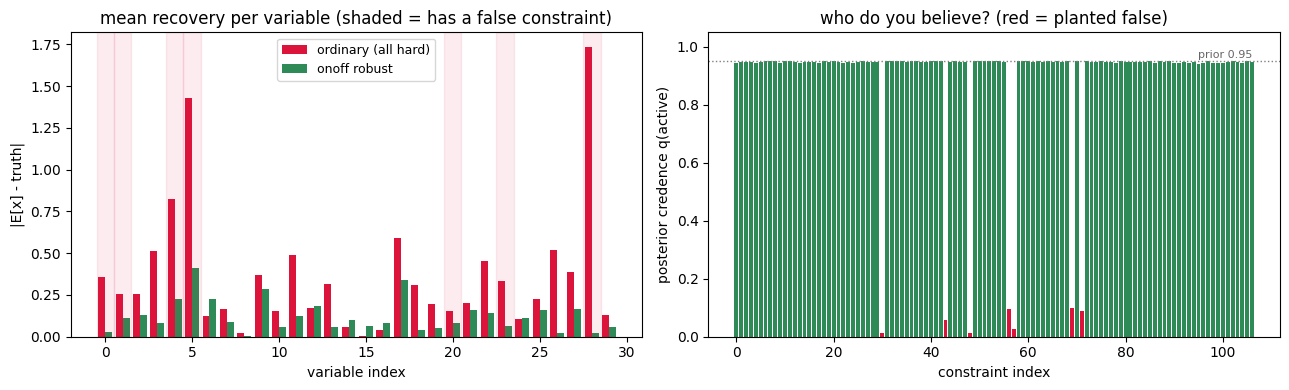

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# left: per-variable mean recovery, ordinary vs robust (shaded = has a false constraint)
x = np.arange(NV); w = 0.4
ax[0].bar(x - w/2, err_h, w, color="crimson",  label="ordinary (all hard)")
ax[0].bar(x + w/2, err_r, w, color="seagreen", label="onoff robust")
for v in false_vars:
    ax[0].axvspan(v - 0.5, v + 0.5, color="crimson", alpha=0.08)
ax[0].set_xlabel("variable index"); ax[0].set_ylabel("|E[x] - truth|")
ax[0].set_title("mean recovery per variable (shaded = has a false constraint)")
ax[0].legend(fontsize=9)

# right: credence per constraint (robust), false ones in red
colors = ["crimson" if f else "seagreen" for f in is_false]
ax[1].bar(range(len(cons)), cred, color=colors)
ax[1].axhline(0.95, color="0.5", lw=1, ls=":")
ax[1].text(len(cons)-1, 0.955, "prior 0.95", fontsize=8, color="0.4", va="bottom", ha="right")
ax[1].set_xlabel("constraint index"); ax[1].set_ylabel("posterior credence q(active)")
ax[1].set_title("who do you believe? (red = planted false)"); ax[1].set_ylim(0, 1.05)
fig.tight_layout(); _FIG1 = fig

pairwise-product (constrained covariances) mean |model-truth|:  robust 9.1   hard 28.1


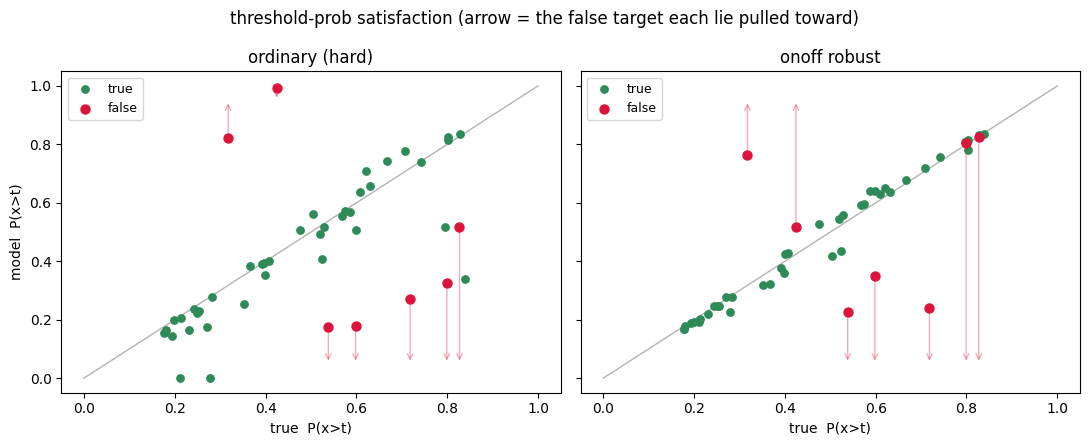

In [5]:
# constraint satisfaction on the threshold-probs (all on a [0,1] scale, incl. the lies):
# model P(x_i>t) vs the TRUE probability. Robust should keep the reds on the diagonal
# (it followed the truth and convicted the lie); hard is dragged toward the false target.
pk = [k for k in range(len(cons)) if cons[k]["kind"] == "prob"]
true_p = np.array([float(np.mean(Xref[:, cons[k]["_pi"]] > cons[k]["_pt"])) for k in pk])
mp_r = np.array([sm_r.expectation(p_r, hard_gt(cons[k]["_pi"], cons[k]["_pt"])) for k in pk])
mp_h = np.array([sm_h.expectation(p_h, hard_gt(cons[k]["_pi"], cons[k]["_pt"])) for k in pk])
fmask = np.array([cons[k]["is_false"] for k in pk])

fig2, ax = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for a, mp, title in ((ax[0], mp_h, "ordinary (hard)"), (ax[1], mp_r, "onoff robust")):
    a.plot([0, 1], [0, 1], "0.7", lw=1, zorder=0)
    a.scatter(true_p[~fmask], mp[~fmask], c="seagreen", s=28, label="true", zorder=2)
    a.scatter(true_p[fmask],  mp[fmask],  c="crimson",  s=42, label="false", zorder=3)
    for kk, k in enumerate(pk):            # arrow: where each lie WANTED to pull the model
        if cons[k]["is_false"]:
            a.annotate("", xy=(true_p[kk], cons[k]["target"]), xytext=(true_p[kk], mp[kk]),
                       arrowprops=dict(arrowstyle="->", color="crimson", alpha=0.35))
    a.set_xlabel("true  P(x>t)"); a.set_title(title); a.legend(fontsize=9)
ax[0].set_ylabel("model  P(x>t)")
fig2.suptitle("threshold-prob satisfaction (arrow = the false target each lie pulled toward)")
fig2.tight_layout(); _FIG2 = fig2

covF_constrained = None
prodk = [k for k in range(len(cons)) if cons[k]["kind"] == "prod"]
if prodk:
    tp = np.array([cons[k]["true_target"] for k in prodk])
    er = np.array([abs(sm_r.expectation(p_r, cons[k]["f"]) - cons[k]["true_target"]) for k in prodk])
    eh = np.array([abs(sm_h.expectation(p_h, cons[k]["f"]) - cons[k]["true_target"]) for k in prodk])
    print(f"pairwise-product (constrained covariances) mean |model-truth|:"
          f"  robust {er.mean():.1f}   hard {eh.mean():.1f}")

## 4. Sampling the fitted model — pairwise marginals

The whole point of a sampler is that drawing from it is trivial. Here is a corner plot of a batch
of samples from the **robust** fit, over a subset of variables chosen to be mutually correlated (a
false-constrained variable and its most-correlated partners), with the **ground-truth** marginals
overlaid in red. It shows the sampler both recovered the true 1-D marginals — including on the
variable whose constraint we convicted — and captured the low-rank *correlation* structure (tilted
2-D panels), none of which was directly constrained beyond a handful of pairwise products.

pairwise subset (sites): [0, 3, 8, 9, 29]  seed_var (had a false constraint): 0


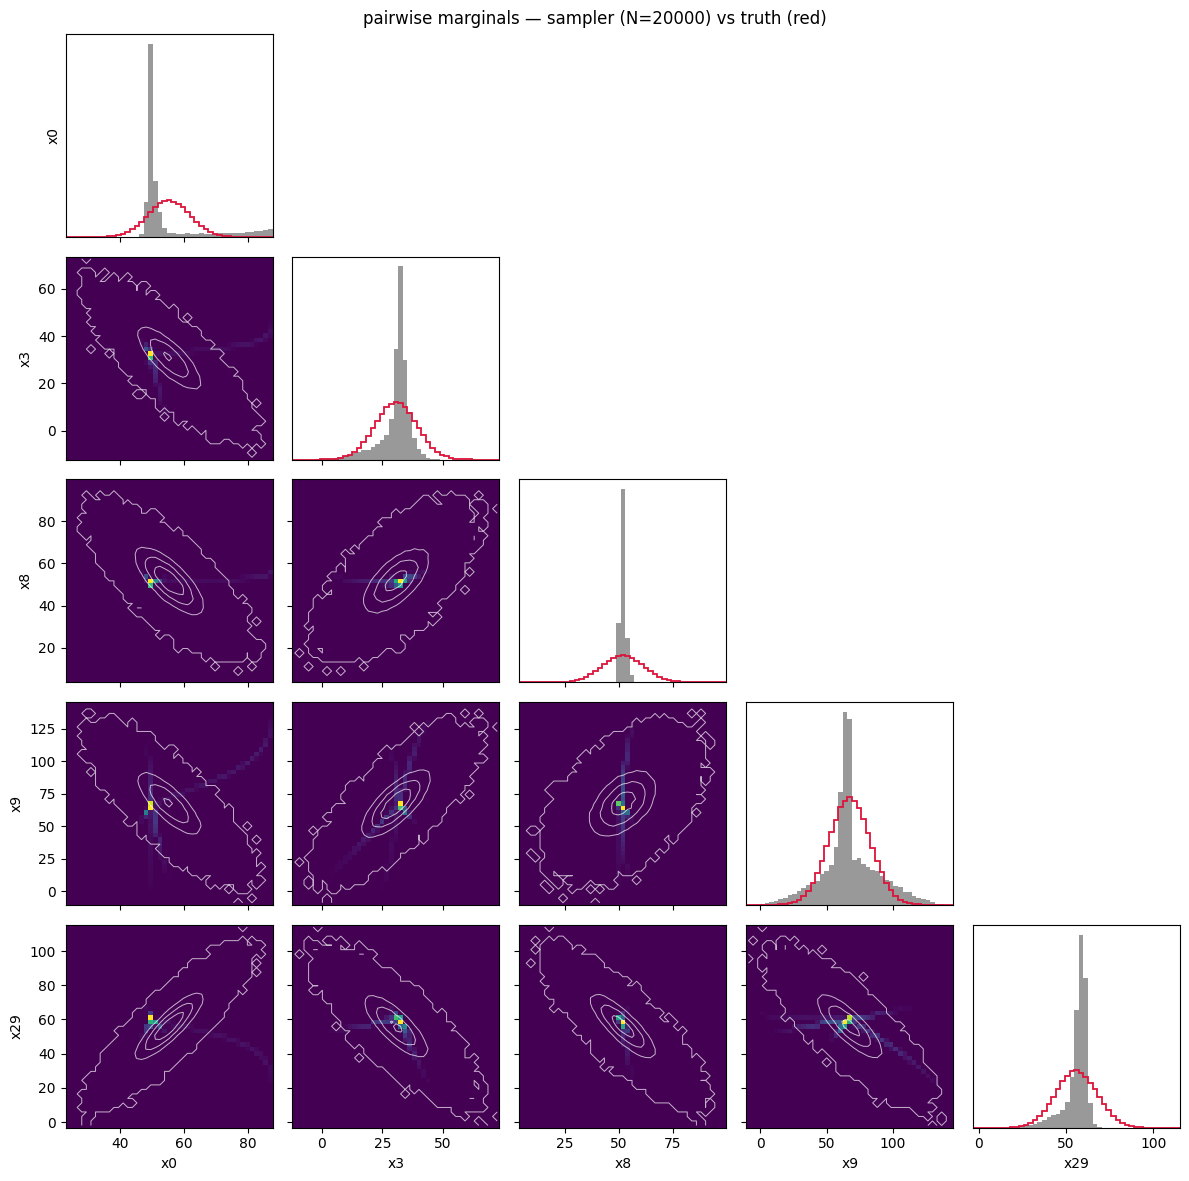

In [6]:
# subset: a false-constrained variable + its 4 most-correlated partners
corr = Sigma / np.outer(sd, sd)
seed_var = false_vars[0]
partners = [int(j) for j in np.argsort(-np.abs(corr[seed_var])) if j != seed_var][:4]
sites = sorted({seed_var, *partners})
print("pairwise subset (sites):", sites, " seed_var (had a false constraint):", seed_var)

_FIG3 = plot_pairwise(sm_r, p_r, sites=sites, names=[f"x{i}" for i in sites],
                      n_samples=20000, seed=1, bins=45,
                      ref_samples=Xref[:, sites])[0]

## 5. (Experimental) Credences as sampled latents — the tn-style variant

The `onoff` credences above are learnable **gate parameters**. The tensor-network robust losses instead
treat each credence as a **latent variable** of the model. `LatentCredenceModel` does the same here: the
sampler emits the 30 data variables **plus one `(0,1)` credence latent per constraint** (137 outputs), and
each credence is that latent's marginal `q_k = E_z[c_k]`, read by **sampling** rather than off the params —
the literal "30 data + 107 binary constraint variables" picture.

It is heavier (a 137-output network; the loss can take a couple of minutes to compile) and, because the
`onoff` free energy couples only the latent *marginals*, the sampled latents share the sampler trunk with
the data with no offsetting benefit — so at this scale it separates the lies **less cleanly** than the gate
parameterisation. Run it to see the mechanism and the tradeoff.

In [7]:
from calibrated_response.maxent_sampler import LatentCredenceModel

mL = LatentCredenceModel(vars, n_credences=len(cons), latent_dim=8, hidden_sizes=[128, 128])
pL, histL = mL.optimize(mL.constraint_loss(onoff_list, n_samples=NS),
                        backend="adam", steps=STEPS, lr=LR)         # note: slow to compile

credL = mL.credences(pL)                              # marginal credence per constraint, by sampling
Csamp = mL.credence_samples(pL, 20000, seed=7)        # (N, n_constraints) per-sample latent draws
ttL, tfL = credL[~is_false], credL[is_false]
aucL = np.mean([1.0*(a < b) + 0.5*(a == b) for a in tfL for b in ttL])
meanL = np.abs(mL.sample(pL, 20000, seed=7).mean(0) - mu)
print(f"latent credences:  separation AUC = {aucL:.3f}   (gate version was {auc:.3f})")
print(f"  credence TRUE mean {ttL.mean():.2f}   FALSE mean {tfL.mean():.2f}")
print(f"  mean recovery |E[x]-mu| = {meanL.mean():.2f} (max {meanL.max():.2f})")

latent credences:  separation AUC = 0.794   (gate version was 1.000)
  credence TRUE mean 0.87   FALSE mean 0.42
  mean recovery |E[x]-mu| = 1.18 (max 12.46)


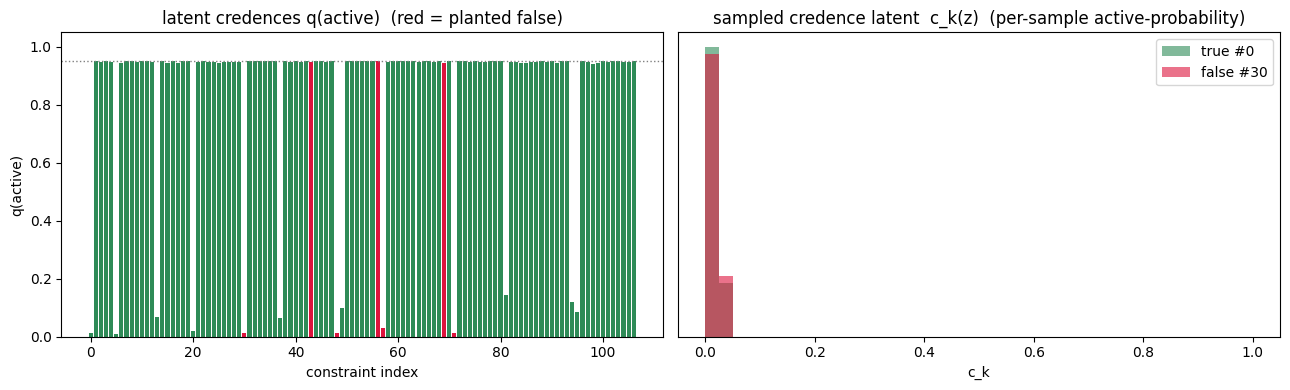

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(range(len(cons)), credL, color=["crimson" if f else "seagreen" for f in is_false])
ax[0].axhline(0.95, color="0.5", lw=1, ls=":")
ax[0].set_title("latent credences q(active)  (red = planted false)")
ax[0].set_xlabel("constraint index"); ax[0].set_ylabel("q(active)"); ax[0].set_ylim(0, 1.05)

# the new thing this variant lets us do: SAMPLE the credence latent and look at its spread
kf = int(sorted(false_k)[0]); kt = int(np.where(~is_false)[0][0])
ax[1].hist(Csamp[:, kt], bins=40, range=(0, 1), color="seagreen", alpha=0.6, density=True,
           label=f"true #{kt}")
ax[1].hist(Csamp[:, kf], bins=40, range=(0, 1), color="crimson", alpha=0.6, density=True,
           label=f"false #{kf}")
ax[1].set_title("sampled credence latent  c_k(z)  (per-sample active-probability)")
ax[1].set_xlabel("c_k"); ax[1].set_yticks([]); ax[1].legend()
fig.tight_layout(); _FIG4 = fig

## What to take away

- **The sampler self-arbitrates at scale.** All 7 planted lies convict (`credence → ~0.05`) while the
  100 true statements sit at the prior `0.95` — perfect separation, no flag supplied. The credence bar
  chart *names the culprits*.
- **Robust recovery beats hard.** The ordinary fit lets the 7 false probabilities drag their variables'
  means and marginals off the truth; the robust fit switches those constraints off and lands back on the
  ground-truth distribution.
- **107 "constraint variables" cost 107 scalars, not 107 dimensions.** In the tensor network each robust
  constraint is a latent *site* (a 137-site chain here); in the sampler it is one credence *gate
  parameter* on a 30-output network. The KL is a closed-form Bernoulli KL — no bins, no histogram, no MMD.
  §5 implements the literal latent-variable version (`LatentCredenceModel`) for comparison — it reproduces
  the picture but optimises less cleanly at this scale (the credence latents share the sampler trunk with
  the data, and the `onoff` coupling only uses their marginals), which is why the **gate is the default**.

Honest limits: a constraint on a genuinely *unconstrained* degree of freedom (e.g. a covariance no other
constraint touches) cannot be falsified, so only over-determined lies are convicted — which is why the
lies here are planted on variables whose means anchor them. And a perfectly symmetric conflict is
convicted arbitrarily rather than hedged.